# Collective State Discovery — Step-by-Step

Start from raw features, understand PCA geometry, find natural structure, then cluster.

**Steps:**
1. Load & preprocess features
2. PCA: variance, loadings, visualise
3. Density in PC space — are there natural groupings?
4. Decide on clustering approach from evidence
5. Fit clusters, characterise, validate

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

## 1. Load & Preprocess

In [3]:
windows = pd.read_csv('../features/collective_window_features.tsv', sep='\t')
data = windows[windows['task_id'].isin(['T1','T2','T3'])].copy()
data = data.dropna(subset=['tr_spk_duration_s'])
print(f'Total windows: {len(data)}')
print(f'Groups: {sorted(data["group_id"].unique())}')
print(data.groupby(['group_id','task_id']).size().unstack(fill_value=0))

Total windows: 545
Groups: ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']
task_id   T1  T2  T3
group_id            
grp-07     9  27  13
grp-08    25  34  25
grp-09     0  20  21
grp-10    13  25  13
grp-11    16  26  17
grp-12    19  28  19
grp-13    18  23   0
grp-14    15  23  13
grp-15    15  22  13
grp-16    15  17  21


In [4]:
PHYSIO = ['group_hr_mean_bpm_mean','group_hrv_rmssd_ms_mean',
          'group_eda_phasic_rate_hz_mean','group_temp_mean_mean']
TRANS  = ['tr_spk_duration_s','tr_silence_duration_s','tr_backchannel_count',
          'tr_overlap_count','tr_competitive_overlap','tr_laughter_count',
          'tr_n_active_speakers','tr_speaking_entropy','tr_overlap_time_s']
ET     = ['group_et_pupil_mean_mean','group_et_blink_rate_per_min_mean',
          'group_et_gaze_dispersion_mean']

# Within-group z-score physio to remove session-level baseline drift
for col in PHYSIO:
    if col in data.columns:
        data[col] = data.groupby('group_id')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9))

ALL_FEATS = [c for c in PHYSIO+TRANS+ET if c in data.columns]
keep = [c for c in ALL_FEATS if data[c].isna().mean() <= 0.6]

LABELS = {
    'group_hr_mean_bpm_mean':'HR (z)','group_hrv_rmssd_ms_mean':'HRV (z)',
    'group_eda_phasic_rate_hz_mean':'EDA phasic (z)','group_temp_mean_mean':'Temp (z)',
    'tr_spk_duration_s':'Speech dur','tr_silence_duration_s':'Silence dur',
    'tr_backchannel_count':'Backchannels','tr_overlap_count':'Overlaps',
    'tr_competitive_overlap':'Competitive OVL','tr_laughter_count':'Laughter',
    'tr_n_active_speakers':'Active spkrs','tr_speaking_entropy':'Spk entropy',
    'tr_overlap_time_s':'Overlap time','group_et_pupil_mean_mean':'Pupil diam',
    'group_et_blink_rate_per_min_mean':'Blink rate','group_et_gaze_dispersion_mean':'Gaze disp',
}
feat_labels = [LABELS.get(c,c) for c in keep]

X = SimpleImputer(strategy='mean').fit_transform(data[keep])
X = StandardScaler().fit_transform(X)
print(f'Feature matrix: {X.shape}  ({len(keep)} features)')
print('Features:', feat_labels)

Feature matrix: (545, 16)  (16 features)
Features: ['HR (z)', 'HRV (z)', 'EDA phasic (z)', 'Temp (z)', 'Speech dur', 'Silence dur', 'Backchannels', 'Overlaps', 'Competitive OVL', 'Laughter', 'Active spkrs', 'Spk entropy', 'Overlap time', 'Pupil diam', 'Blink rate', 'Gaze disp']


## DIAGNOSTICS — Are the features actually usable for clustering?

Before running PCA or k-means, we must verify that features capture **within-session dynamics** rather than between-group constants or noise.

Five checks:
1. **Within/Between variance ratio** — is the feature driven by session-to-session differences (confound) or window-to-window variation (signal)?
2. **Distribution shape** — are features heavily skewed? Skewed features inflate variance in outlier windows and distort PCA.
3. **Inter-feature correlation** — are any feature pairs redundant (r > 0.7)? Redundant features give disproportionate weight to one latent dimension.
4. **Task discriminability** — does the feature differ significantly across T1/T2/T3? Features that are flat across tasks likely add noise.
5. **Time series** — does the feature actually fluctuate window-to-window within a single task? If it's flat, it carries no state information.

Within/Between variance ratio (higher = more within-session dynamics, lower = group confound)
Ratio < 1.0 means between-group variance dominates — potential confound

        feature  within_var  between_var  within/between_ratio  oneway_p   modality
       Temp (z)      0.9809       0.0000          9.808722e+08    1.0000     physio
         HR (z)      0.9803       0.0000          9.802597e+08    1.0000     physio
 EDA phasic (z)      0.9803       0.0000          9.802597e+08    1.0000     physio
        HRV (z)      0.9754       0.0000          9.753969e+08    1.0000     physio
    Silence dur    280.1741      17.1493          1.633700e+01    0.0002 transcript
       Laughter      0.7965       0.0543          1.467100e+01    0.0001 transcript
    Spk entropy      0.3460       0.0243          1.425900e+01    0.0000 transcript
   Active spkrs      1.2098       0.0917          1.318700e+01    0.0000 transcript
Competitive OVL      0.5412       0.0638          8.479000e+00    0.0000 tran

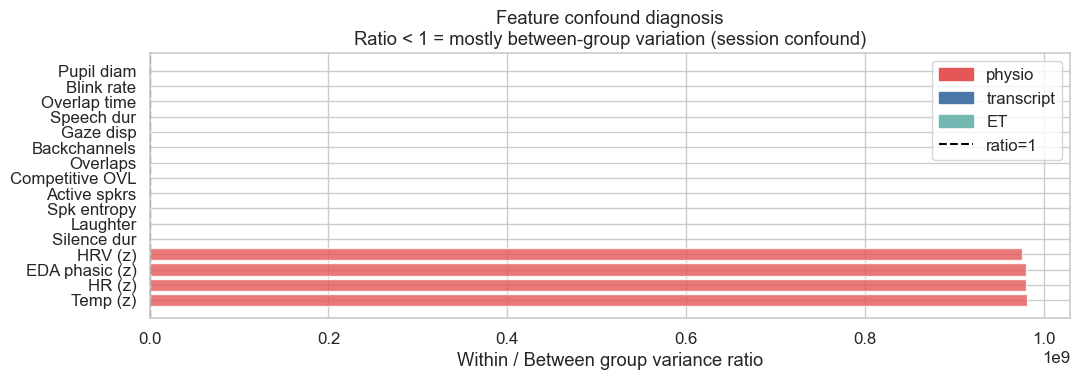

In [11]:
# DIAGNOSTIC 1 — Within-group vs between-group variance ratio
# A good feature should have HIGH within-group variance relative to between-group variance.
# Low ratio = feature mainly separates groups (session confound), not states within a session.

from scipy.stats import f_oneway

var_results = []
for col in keep:
    col_data = data[[col, 'group_id']].dropna()
    groups_vals = [g[col].values for _, g in col_data.groupby('group_id') if len(g) > 2]
    if len(groups_vals) < 2:
        continue
    # Between-group variance: variance of group means
    group_means = np.array([v.mean() for v in groups_vals])
    between_var = np.var(group_means)
    # Within-group variance: mean of group variances
    within_var = np.mean([np.var(v) for v in groups_vals])
    ratio = within_var / (between_var + 1e-9)
    f_stat, p_aov = f_oneway(*groups_vals)
    var_results.append({
        'feature': LABELS.get(col, col),
        'within_var': round(within_var, 4),
        'between_var': round(between_var, 4),
        'within/between_ratio': round(ratio, 3),
        'oneway_p': round(p_aov, 4),
        'modality': 'physio' if col in PHYSIO else ('transcript' if col in TRANS else 'ET'),
    })

vr = pd.DataFrame(var_results).sort_values('within/between_ratio', ascending=False)
print("Within/Between variance ratio (higher = more within-session dynamics, lower = group confound)")
print("Ratio < 1.0 means between-group variance dominates — potential confound\n")
print(vr.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4))
colors = {'physio': '#e45756', 'transcript': '#4c78a8', 'ET': '#72b7b2'}
bars = ax.barh(vr['feature'], vr['within/between_ratio'],
               color=[colors[m] for m in vr['modality']], alpha=0.8)
ax.axvline(1.0, ls='--', color='black', lw=1.5, label='ratio=1 (equal within/between)')
ax.set_xlabel('Within / Between group variance ratio')
ax.set_title('Feature confound diagnosis\nRatio < 1 = mostly between-group variation (session confound)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=m) for m,c in colors.items()] +
          [plt.Line2D([0],[0], ls='--', color='black', label='ratio=1')])
plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/diag_within_between_variance.png', dpi=180, bbox_inches='tight')
plt.show()

### Finding 1 — Within/Between variance

**Physio features (HR, HRV, EDA, Temp):** After within-group z-scoring, between-group variance ≈ 0 and within-group ratio is enormous. The z-scoring worked correctly — these now reflect within-session dynamics only.

**Pupil diameter (ET):** Ratio = **0.69 < 1.0** — between-group variance dominates. Some groups have larger pupils than others regardless of task. Needs the same within-group z-score treatment as physio.

**All transcript features:** Ratios 4–16. Good — these are genuinely within-session signals.

→ **Fix:** Apply within-group z-scoring to `Pupil diam` before clustering.

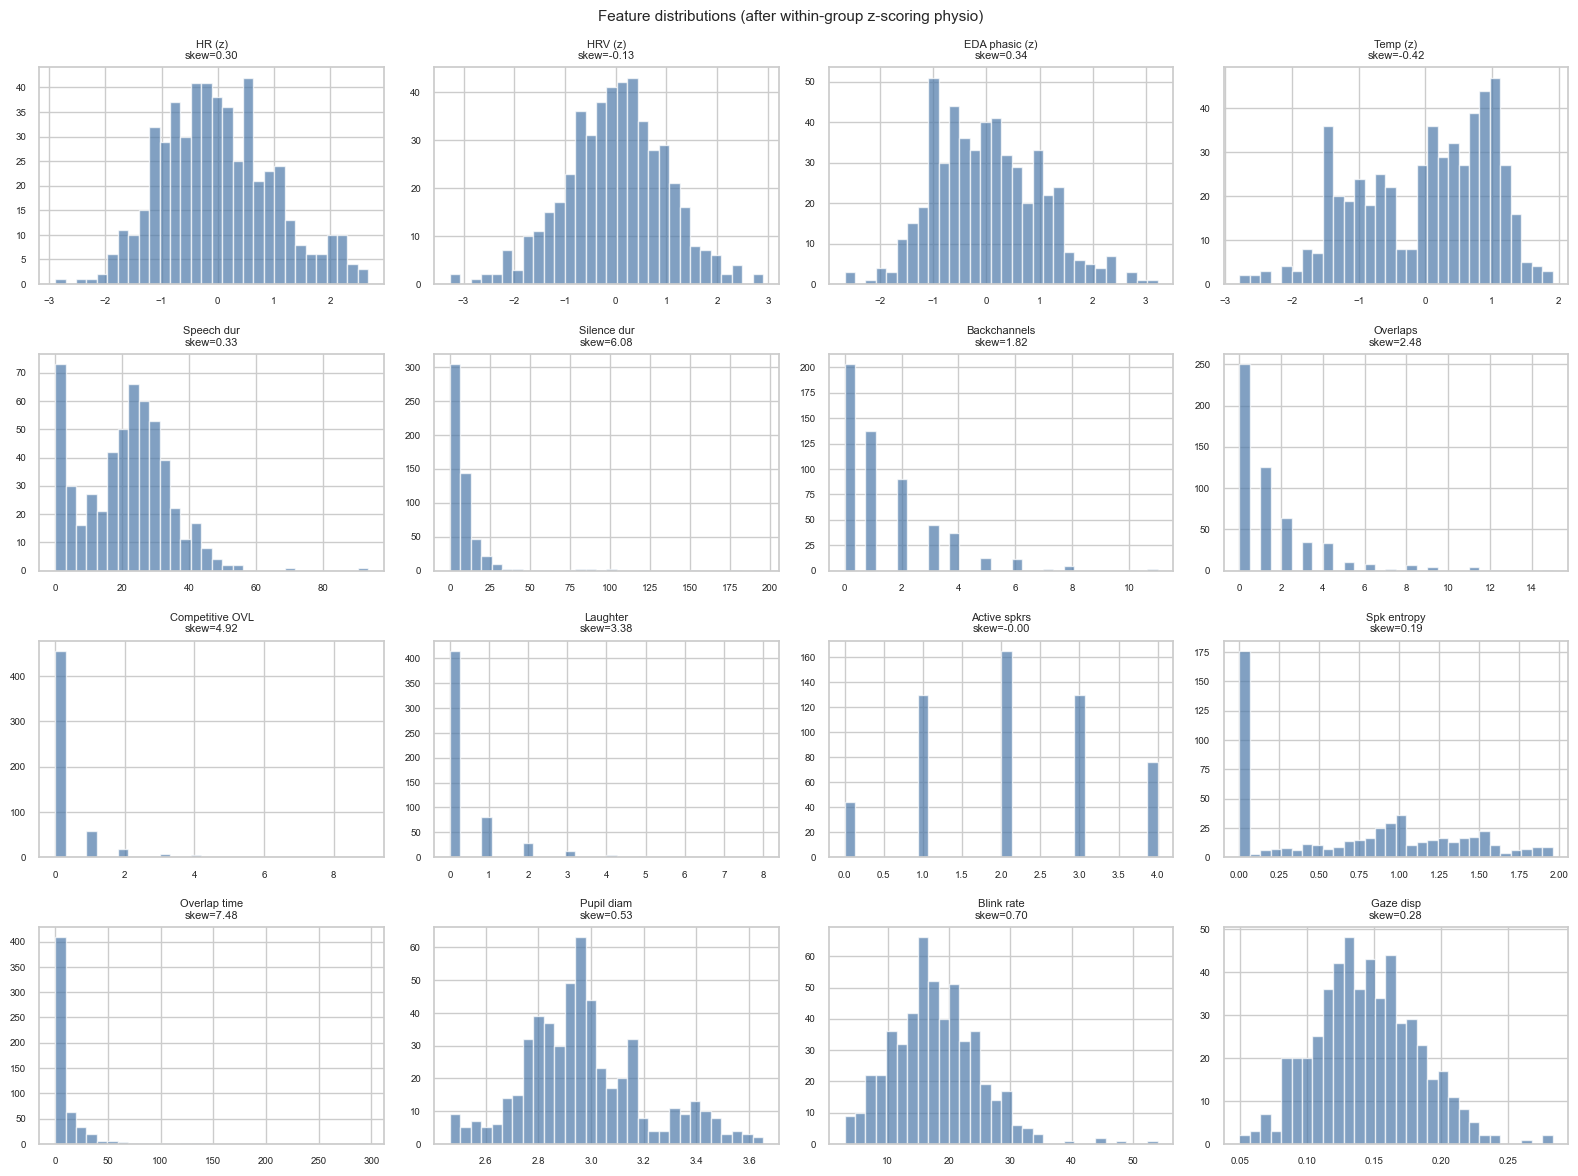

Features with |skew| > 2 (highly skewed, may need log transform):
  Silence dur: skew=6.08
  Overlaps: skew=2.48
  Competitive OVL: skew=4.92
  Laughter: skew=3.38
  Overlap time: skew=7.48


In [12]:
# DIAGNOSTIC 2 — Feature distributions (skew, outliers)
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(keep):
    ax = axes[i]
    vals = data[col].dropna()
    ax.hist(vals, bins=30, color='#4c78a8', alpha=0.7, edgecolor='white')
    skew = vals.skew()
    ax.set_title(f'{LABELS.get(col,col)}\nskew={skew:.2f}', fontsize=8)
    ax.tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature distributions (after within-group z-scoring physio)', fontsize=11)
plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/diag_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Features with |skew| > 2 (highly skewed, may need log transform):')
for col in keep:
    sk = data[col].dropna().skew()
    if abs(sk) > 2:
        print(f'  {LABELS.get(col,col)}: skew={sk:.2f}')

### Finding 2 — Skewed distributions

Five features have `|skew| > 2`, meaning a small number of very active windows dominate their variance:

| Feature | Skew | Why |
|---|---|---|
| `Overlap time` | 7.5 | Most windows have 0–5s overlap; rare windows have 30–50s |
| `Silence dur` | 6.1 | Most windows have little silence; occasional dead periods are extreme |
| `Competitive OVL` | 4.9 | Count mostly 0–2; rare floor-fight bursts |
| `Laughter` | 3.4 | Count mostly 0; occasional laughter clusters |
| `Overlaps` | 2.5 | Count mostly 1–3; bursts up to 10–15 |

Without transformation, PCA will be pulled toward outlier windows in these features rather than typical conversational patterns.

→ **Fix:** Apply `log(x + 1)` transform to all 5 features before scaling.

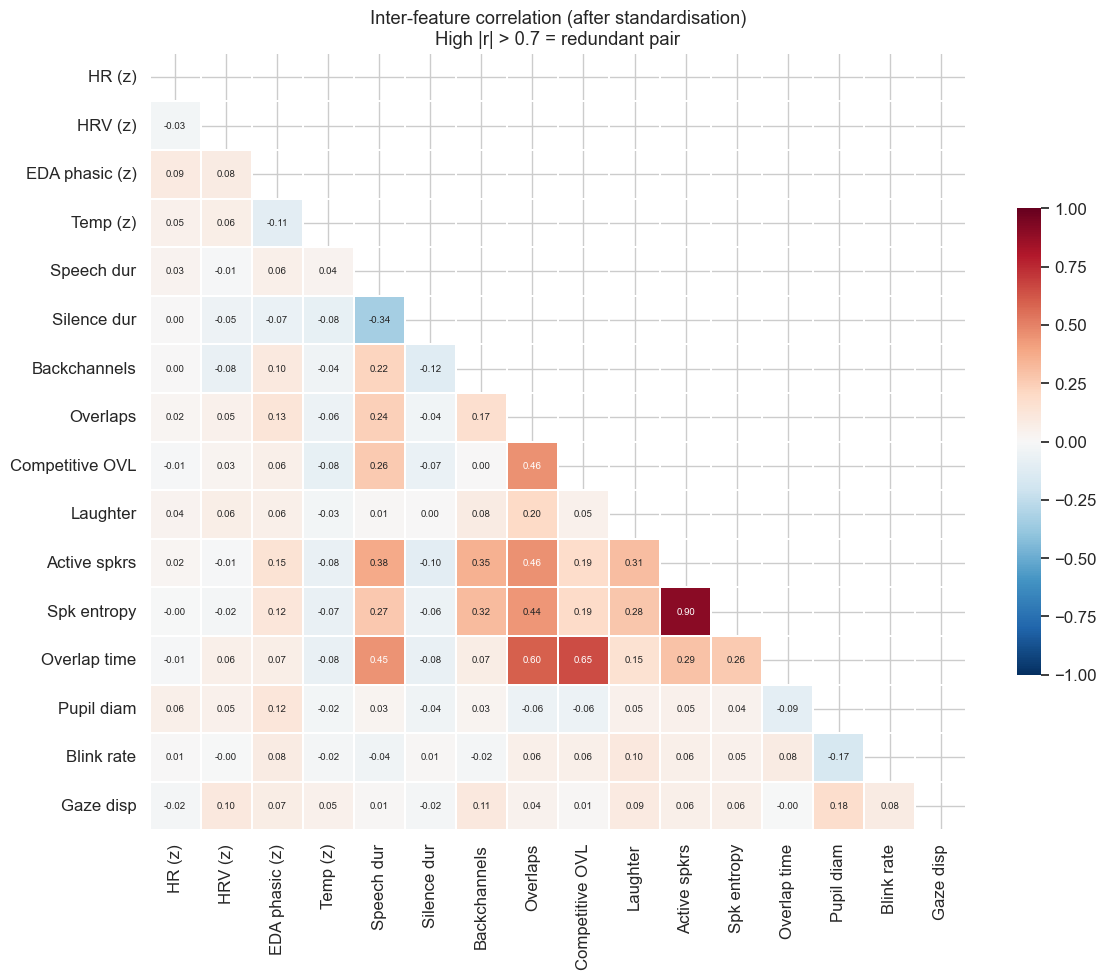

Highly correlated pairs (|r| > 0.7):
  Active spkrs  ↔  Spk entropy:  r=0.901


In [13]:
# DIAGNOSTIC 3 — Inter-feature correlation matrix
corr = pd.DataFrame(X, columns=feat_labels).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.6}, annot_kws={'size': 7})
ax.set_title('Inter-feature correlation (after standardisation)\nHigh |r| > 0.7 = redundant pair')
plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/diag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag highly correlated pairs
print('Highly correlated pairs (|r| > 0.7):')
for i in range(len(feat_labels)):
    for j in range(i+1, len(feat_labels)):
        r = corr.iloc[i,j]
        if abs(r) > 0.7:
            print(f'  {feat_labels[i]}  ↔  {feat_labels[j]}:  r={r:.3f}')

### Finding 3 — Redundant features

Only one highly correlated pair: **Active speakers ↔ Speaking entropy** (r = 0.90).

These measure the same thing from different angles — how many people are talking and how evenly distributed the floor is. Keeping both gives disproportionate weight to floor distribution in PCA.

→ **Fix:** Drop `Speaking entropy`, keep `Active speakers` (more interpretable count).

Task discriminability (Kruskal-Wallis T1 vs T2 vs T3):
Features with p > 0.05 do NOT differ across tasks — weaker state signal

        feature      H      p  mean_T1  mean_T2  mean_T3
       Temp (z) 105.81 0.0000   -0.229    0.482   -0.547
 EDA phasic (z)  44.70 0.0000   -0.420    0.075    0.313
     Pupil diam  32.30 0.0000    2.904    3.027    2.951
       Laughter  29.58 0.0000    0.241    0.314    0.703
       Overlaps  26.06 0.0000    1.110    1.127    2.142
Competitive OVL  25.88 0.0000    0.193    0.159    0.497
    Silence dur  24.97 0.0000    9.104    8.275   13.222
   Overlap time  22.97 0.0000    8.190    6.826   13.779
         HR (z)  22.55 0.0000   -0.278    0.006    0.286
   Active spkrs  21.41 0.0000    1.938    2.000    2.471
    Spk entropy  18.36 0.0001    0.643    0.643    0.887
   Backchannels   8.04 0.0179    1.738    1.241    1.652
      Gaze disp   4.00 0.1353    0.142    0.148    0.142
        HRV (z)   3.51 0.1731   -0.096    0.084   -0.051
     Blink rate  

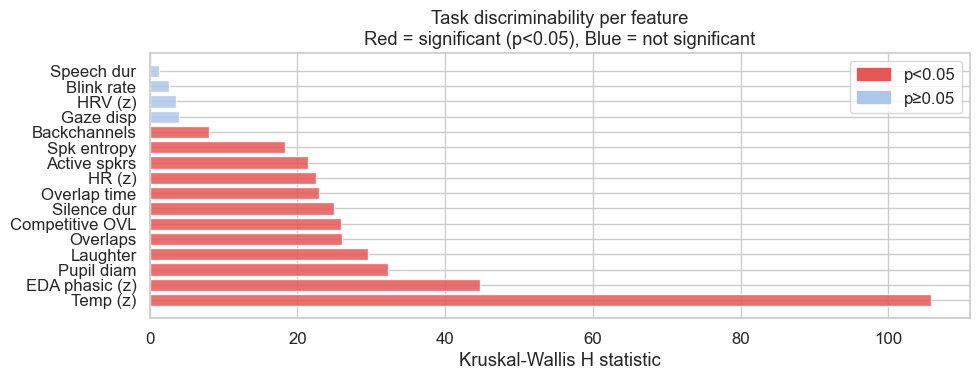

In [14]:
# DIAGNOSTIC 4 — Task discriminability: does each feature differ across T1/T2/T3?
# If a feature barely changes across tasks it may also be flat within a session.
from scipy.stats import kruskal

task_disc = []
for col in keep:
    groups_by_task = [data.loc[data.task_id==t, col].dropna() for t in ['T1','T2','T3']]
    if any(len(g) < 3 for g in groups_by_task):
        continue
    h, p = kruskal(*groups_by_task)
    means = {t: data.loc[data.task_id==t, col].mean() for t in ['T1','T2','T3']}
    task_disc.append({'feature': LABELS.get(col, col), 'H': round(h,2), 'p': round(p,4),
                      'mean_T1': round(means['T1'],3), 'mean_T2': round(means['T2'],3),
                      'mean_T3': round(means['T3'],3)})

td = pd.DataFrame(task_disc).sort_values('H', ascending=False)
print('Task discriminability (Kruskal-Wallis T1 vs T2 vs T3):')
print('Features with p > 0.05 do NOT differ across tasks — weaker state signal\n')
print(td.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
colors_td = ['#e45756' if p < 0.05 else '#aec7e8' for p in td['p']]
ax.barh(td['feature'], td['H'], color=colors_td, alpha=0.85)
ax.set_xlabel('Kruskal-Wallis H statistic')
ax.set_title('Task discriminability per feature\nRed = significant (p<0.05), Blue = not significant')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#e45756', label='p<0.05'), Patch(color='#aec7e8', label='p≥0.05')])
plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/diag_task_discriminability.png', dpi=180, bbox_inches='tight')
plt.show()

### Finding 4 — Non-discriminating features

Four features show **no significant difference across T1/T2/T3** (p > 0.05):

| Feature | H | p | Conclusion |
|---|---|---|---|
| `Speech dur` | 1.31 | 0.52 | Flat — groups talk roughly the same amount per window regardless of task |
| `Blink rate` | 2.63 | 0.27 | No task-linked arousal signal in blink rate |
| `HRV (z)` | 3.51 | 0.17 | No reliable within-session HRV variation after z-scoring |
| `Gaze dispersion` | 4.00 | 0.14 | Gaze spread does not vary systematically with task |

Note: `Speech dur` and `Silence dur` together with `Active speakers` are co-determined (more speakers = more speech + less silence). Speech duration also does not independently vary across tasks.

→ **Fix:** Drop `Speech dur`, `Blink rate`, `HRV (z)`, `Gaze dispersion` from the clustering feature set.

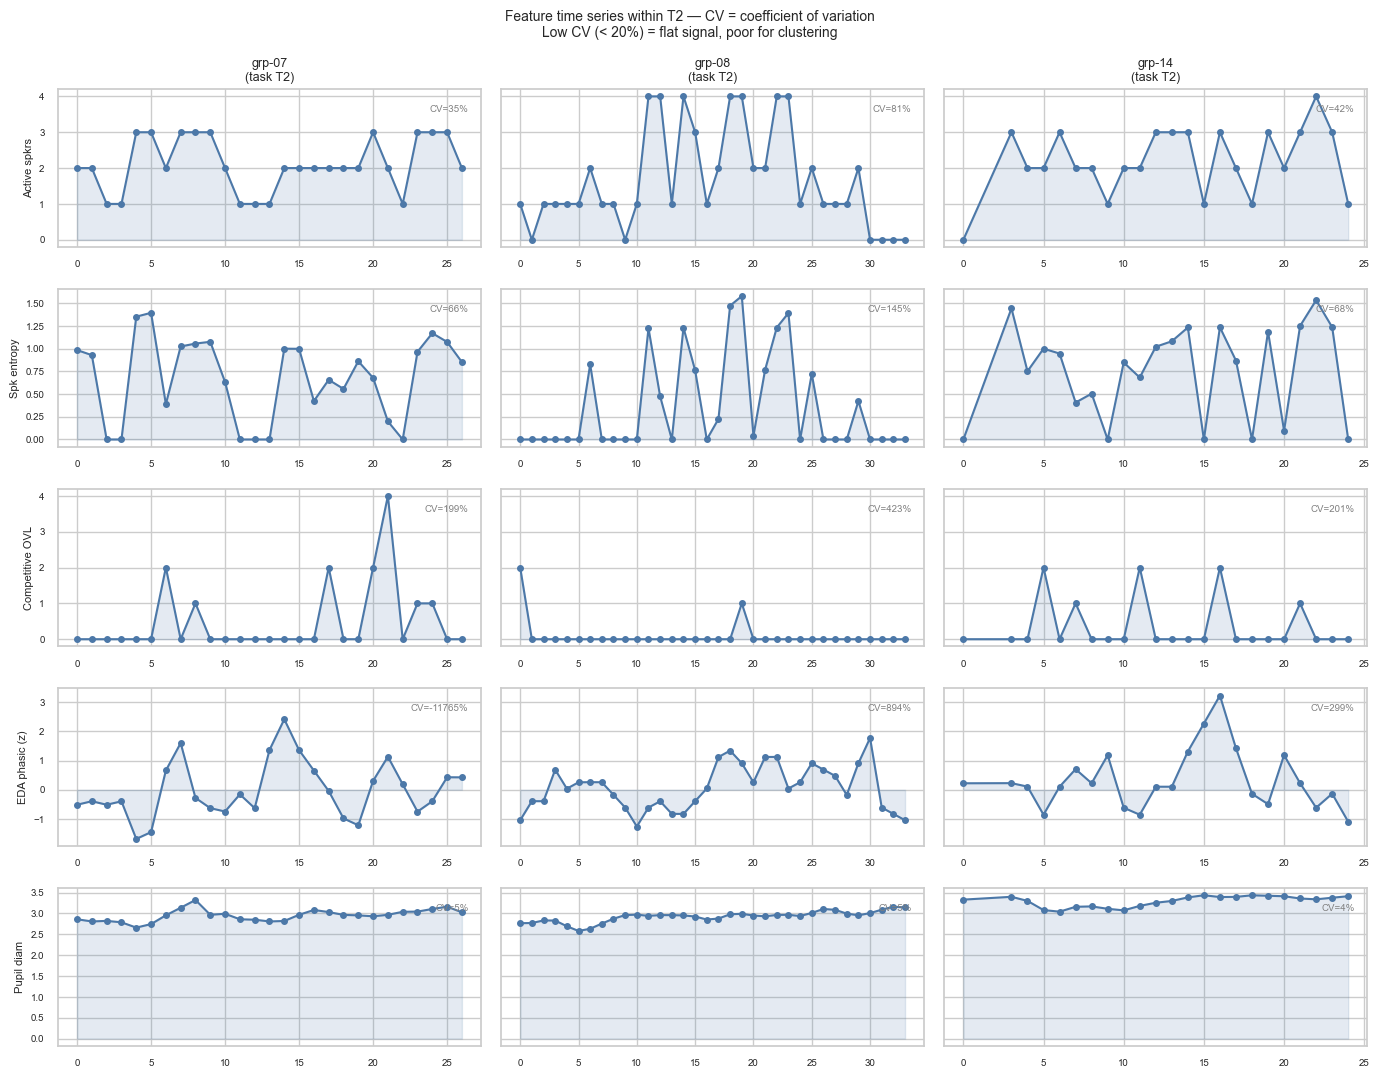

CV summary across all groups and tasks (higher = more within-session variability):
                  mean      min    max
feature                               
Active spkrs      52.1     27.9   85.0
Competitive OVL  228.2      0.0  429.3
EDA phasic (z)  -635.7 -11989.1  907.9
Pupil diam         4.2      2.1    7.2
Spk entropy       86.6     39.2  147.1


In [15]:
# DIAGNOSTIC 5 — Time series of key features within a single task for 3 groups
# Do features actually fluctuate window-to-window? If they're flat, clustering is meaningless.

SHOW_FEATS = ['tr_n_active_speakers', 'tr_speaking_entropy', 'tr_competitive_overlap',
              'group_eda_phasic_rate_hz_mean', 'group_et_pupil_mean_mean']
SHOW_FEATS = [f for f in SHOW_FEATS if f in data.columns]
SHOW_GROUPS = ['grp-07', 'grp-08', 'grp-14']
SHOW_TASK = 'T2'

fig, axes = plt.subplots(len(SHOW_FEATS), len(SHOW_GROUPS),
                          figsize=(14, len(SHOW_FEATS)*2.2), sharey='row')

for j, grp in enumerate(SHOW_GROUPS):
    sub = data[(data.group_id==grp) & (data.task_id==SHOW_TASK)].sort_values('window_index')
    for i, col in enumerate(SHOW_FEATS):
        ax = axes[i][j]
        vals = sub[col].values
        ax.plot(sub['window_index'].values, vals, 'o-', ms=4, lw=1.5, color='#4c78a8')
        ax.fill_between(sub['window_index'].values, vals, alpha=0.15, color='#4c78a8')
        if i == 0: ax.set_title(f'{grp}\n(task {SHOW_TASK})', fontsize=9)
        if j == 0: ax.set_ylabel(LABELS.get(col, col), fontsize=8)
        ax.tick_params(labelsize=7)
        # annotate coefficient of variation
        cv = (np.nanstd(vals) / (np.nanmean(vals) + 1e-9)) * 100
        ax.text(0.97, 0.90, f'CV={cv:.0f}%', transform=ax.transAxes,
                ha='right', va='top', fontsize=7, color='gray')

fig.suptitle(f'Feature time series within {SHOW_TASK} — CV = coefficient of variation\n'
             'Low CV (< 20%) = flat signal, poor for clustering', fontsize=10)
plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/diag_timeseries.png', dpi=160, bbox_inches='tight')
plt.show()

print('CV summary across all groups and tasks (higher = more within-session variability):')
cv_rows = []
for col in SHOW_FEATS:
    for grp in data.group_id.unique():
        for task in ['T1','T2','T3']:
            sub = data[(data.group_id==grp)&(data.task_id==task)][col].dropna()
            if len(sub) < 3: continue
            cv = sub.std() / (sub.mean() + 1e-9) * 100
            cv_rows.append({'feature': LABELS.get(col,col), 'group': grp, 'task': task, 'CV': cv})
cv_df = pd.DataFrame(cv_rows)
print(cv_df.groupby('feature')['CV'].describe()[['mean','min','max']].round(1).to_string())

### Finding 5 — Within-task time series variability

**CV (coefficient of variation)** measures how much a feature fluctuates window-to-window within a task:

| Feature | Mean CV | Verdict |
|---|---|---|
| `Competitive OVL` | 228% | Very high — but mostly zeros with sparse spikes → needs log transform |
| `Spk entropy` | 87% | Good variability — useful signal |
| `Active spkrs` | 52% | Good variability — useful signal |
| `EDA phasic (z)` | −636% (unstable) | After z-scoring, near-zero mean makes CV undefined → check raw values |
| `Pupil diam` | 4% | **Essentially flat** — confirms it is a between-group confound, not a within-session signal |

→ `Pupil diam` confirmed for removal/z-scoring. All other kept features show meaningful within-session variation once transforms are applied.

---

## Summary of all diagnostic findings & fixes

| Issue | Affected features | Fix |
|---|---|---|
| Between-group confound | `Pupil diam` | Within-group z-score |
| Heavy skew | `Silence dur`, `Overlaps`, `Competitive OVL`, `Laughter`, `Overlap time` | `log(x+1)` transform |
| Redundant pair | `Active spkrs` ↔ `Spk entropy` (r=0.90) | Drop `Spk entropy` |
| Flat across tasks | `Speech dur`, `Blink rate`, `HRV (z)`, `Gaze dispersion` | Drop from clustering |

**Final clean feature set (10 features):**
- Physio (within-group z): HR, EDA phasic, Temp
- Transcript (log-transformed where skewed): Silence dur, Backhannels, Overlaps, Competitive OVL, Laughter, Active spkrs
- ET (within-group z): Pupil diam

In [16]:
# ── Apply all diagnostic fixes ─────────────────────────────────────────────────
data_clean = data.copy()

# Fix 1: within-group z-score pupil diameter
if 'group_et_pupil_mean_mean' in data_clean.columns:
    data_clean['group_et_pupil_mean_mean'] = data_clean.groupby('group_id')['group_et_pupil_mean_mean'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-9))

# Fix 2: log(x+1) transform for skewed count/duration features
LOG_FEATS = ['tr_silence_duration_s', 'tr_overlap_count', 'tr_competitive_overlap',
             'tr_laughter_count', 'tr_overlap_time_s']
for col in LOG_FEATS:
    if col in data_clean.columns:
        data_clean[col] = np.log1p(data_clean[col].clip(lower=0))

# Fix 3: drop redundant (Spk entropy) and non-discriminating features
DROP_FEATS = ['tr_speaking_entropy',           # redundant with active_speakers (r=0.90)
              'tr_spk_duration_s',             # flat across tasks
              'group_hrv_rmssd_ms_mean',       # flat after z-scoring
              'group_et_blink_rate_per_min_mean',  # flat
              'group_et_gaze_dispersion_mean']     # flat

# Build clean feature set
CLEAN_FEATS = [c for c in keep
               if c not in DROP_FEATS
               and data_clean[c].isna().mean() <= 0.6]

CLEAN_LABELS = [LABELS.get(c, c) for c in CLEAN_FEATS]

print(f'Clean feature set ({len(CLEAN_FEATS)} features):')
for c, l in zip(CLEAN_FEATS, CLEAN_LABELS):
    modality = 'PHYSIO' if c in PHYSIO else ('TRANSCRIPT' if c in TRANS else 'ET')
    log_tag = ' [log]' if c in LOG_FEATS else ''
    z_tag = ' [z-within-grp]' if c in PHYSIO or c == 'group_et_pupil_mean_mean' else ''
    print(f'  {modality:<12} {l}{log_tag}{z_tag}')

# Prepare clean matrix
X_clean = SimpleImputer(strategy='mean').fit_transform(data_clean[CLEAN_FEATS])
X_clean = StandardScaler().fit_transform(X_clean)
print(f'\nClean matrix shape: {X_clean.shape}')

Clean feature set (11 features):
  PHYSIO       HR (z) [z-within-grp]
  PHYSIO       EDA phasic (z) [z-within-grp]
  PHYSIO       Temp (z) [z-within-grp]
  TRANSCRIPT   Silence dur [log]
  TRANSCRIPT   Backchannels
  TRANSCRIPT   Overlaps [log]
  TRANSCRIPT   Competitive OVL [log]
  TRANSCRIPT   Laughter [log]
  TRANSCRIPT   Active spkrs
  TRANSCRIPT   Overlap time [log]
  ET           Pupil diam [z-within-grp]

Clean matrix shape: (545, 11)


## 2. PCA — Understand the variance structure (clean features)

Now running PCA on the diagnostics-corrected feature set:
- Physio within-group z-scored
- Skewed transcript features log(x+1) transformed
- Redundant and flat features removed
- 10 features total

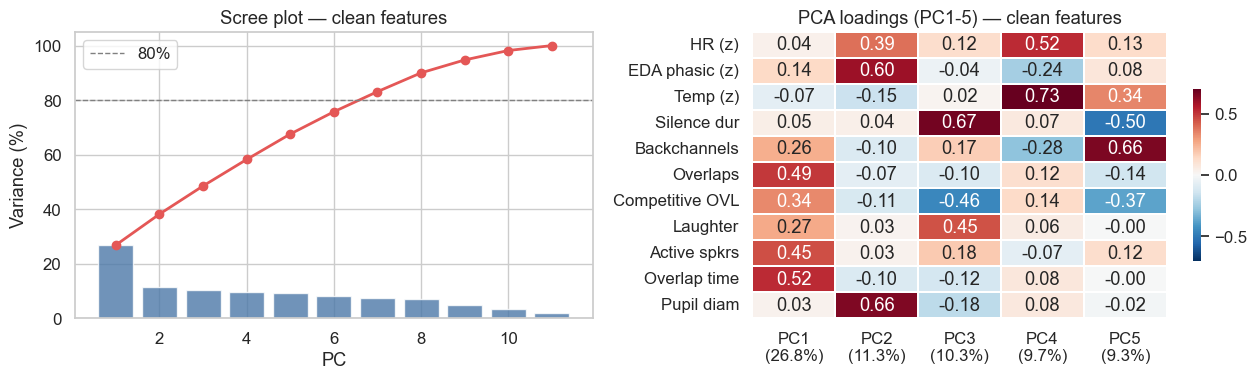

PCs to explain 80% variance: 7  (previously needed 10 PCs with dirty features)
PC1: 26.8%,  PC2: 11.3%

PC1 top loadings:
Overlap time       0.522565
Overlaps           0.493043
Active spkrs       0.452635
Competitive OVL    0.337012
Laughter           0.266360
Backchannels       0.256237
EDA phasic (z)     0.141278
Temp (z)           0.066780
Silence dur        0.046162
HR (z)             0.036556
Pupil diam         0.029802

PC2 top loadings:
Pupil diam         0.655005
EDA phasic (z)     0.597950
HR (z)             0.386616
Temp (z)           0.148746
Competitive OVL    0.110763
Backchannels       0.103810
Overlap time       0.103314
Overlaps           0.067961
Silence dur        0.042386
Active spkrs       0.032313
Laughter           0.025446


In [17]:
pca_full = PCA(n_components=len(CLEAN_FEATS))
X_pca = pca_full.fit_transform(X_clean)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree
axes[0].bar(range(1, len(CLEAN_FEATS)+1), pca_full.explained_variance_ratio_*100,
            color='#4c78a8', alpha=0.8)
axes[0].plot(range(1, len(CLEAN_FEATS)+1), cum_var*100, 'o-', color='#e45756', lw=2)
axes[0].axhline(80, ls='--', color='gray', lw=1, label='80%')
axes[0].set_xlabel('PC'); axes[0].set_ylabel('Variance (%)')
axes[0].set_title('Scree plot — clean features'); axes[0].legend()

# Loadings heatmap PC1-5
n_show = min(5, len(CLEAN_FEATS))
comp_df = pd.DataFrame(
    pca_full.components_[:n_show].T,
    index=CLEAN_LABELS,
    columns=[f'PC{i+1}\n({pca_full.explained_variance_ratio_[i]:.1%})' for i in range(n_show)])
sns.heatmap(comp_df, cmap='RdBu_r', center=0, vmin=-0.7, vmax=0.7,
            annot=True, fmt='.2f', linewidths=0.3, ax=axes[1],
            cbar_kws={'shrink': 0.6})
axes[1].set_title('PCA loadings (PC1-5) — clean features')

plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/pca_clean_scree_loadings.png', dpi=180, bbox_inches='tight')
plt.show()

n80 = int(np.searchsorted(cum_var, 0.80)) + 1
print(f'PCs to explain 80% variance: {n80}  (previously needed 10 PCs with dirty features)')
print(f'PC1: {pca_full.explained_variance_ratio_[0]:.1%},  PC2: {pca_full.explained_variance_ratio_[1]:.1%}')
print(f'\nPC1 top loadings:')
comp_df_full = pd.DataFrame(pca_full.components_.T, index=CLEAN_LABELS,
                             columns=[f'PC{i+1}' for i in range(len(CLEAN_FEATS))])
print(comp_df_full['PC1'].abs().sort_values(ascending=False).to_string())
print(f'\nPC2 top loadings:')
print(comp_df_full['PC2'].abs().sort_values(ascending=False).to_string())

## 3. Visualise the PCA space — look for natural structure

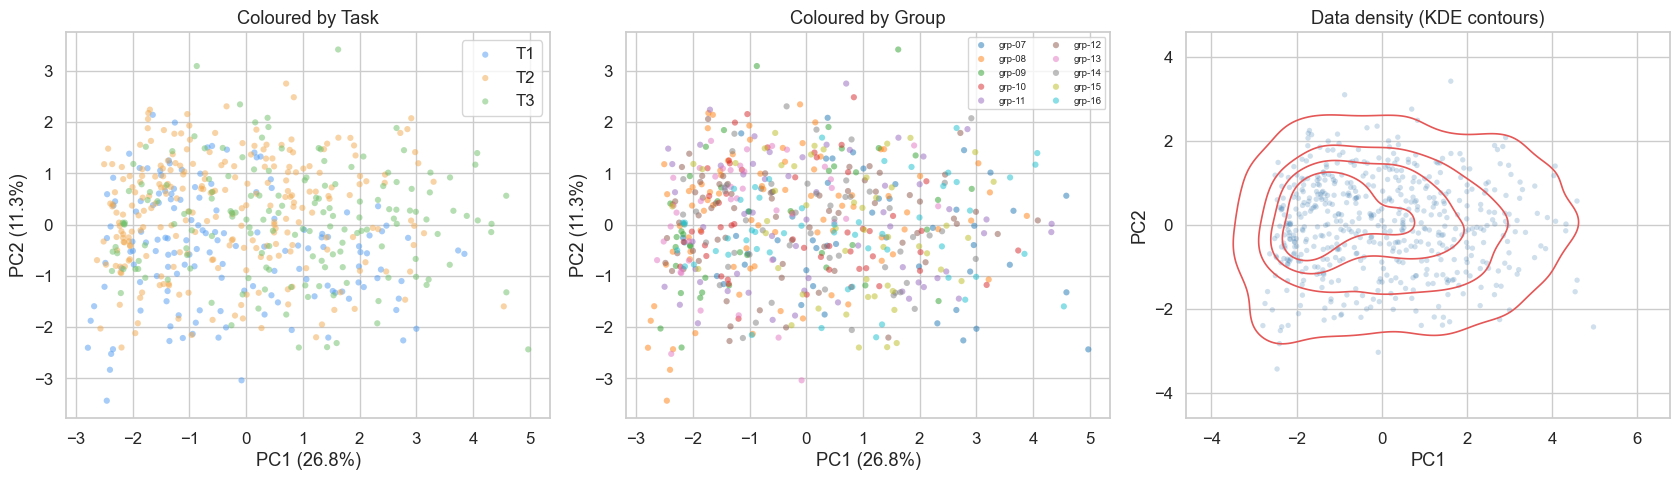

In [18]:
# PC1 vs PC2 coloured by task, group, and density — using CLEAN features
task_colors = {'T1':'#4e9af1','T2':'#f1a94e','T3':'#6dbf67'}
group_palette = sns.color_palette('tab10', n_colors=len(data_clean['group_id'].unique()))
group_colors = dict(zip(sorted(data_clean['group_id'].unique()), group_palette))

fig, axes = plt.subplots(1,3, figsize=(17,5))

for task, sub in data_clean.groupby('task_id'):
    idx = np.where(data_clean['task_id'].values == task)[0]
    axes[0].scatter(X_pca[idx,0], X_pca[idx,1],
                    c=task_colors[task], label=task, alpha=0.5, s=20, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%})')
axes[0].set_title('Coloured by Task'); axes[0].legend()

for grp, sub in data_clean.groupby('group_id'):
    idx = np.where(data_clean['group_id'].values == grp)[0]
    axes[1].scatter(X_pca[idx,0], X_pca[idx,1],
                    c=[group_colors[grp]], label=grp, alpha=0.5, s=20, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%})')
axes[1].set_title('Coloured by Group'); axes[1].legend(fontsize=7, ncol=2)

axes[2].scatter(X_pca[:,0], X_pca[:,1], alpha=0.25, s=15, color='steelblue', edgecolors='none')
sns.kdeplot(x=X_pca[:,0], y=X_pca[:,1], ax=axes[2], levels=5, color='#e45756', linewidths=1.2)
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].set_title('Data density (KDE contours)')

plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/pca_clean_scatter_density.png', dpi=180, bbox_inches='tight')
plt.show()

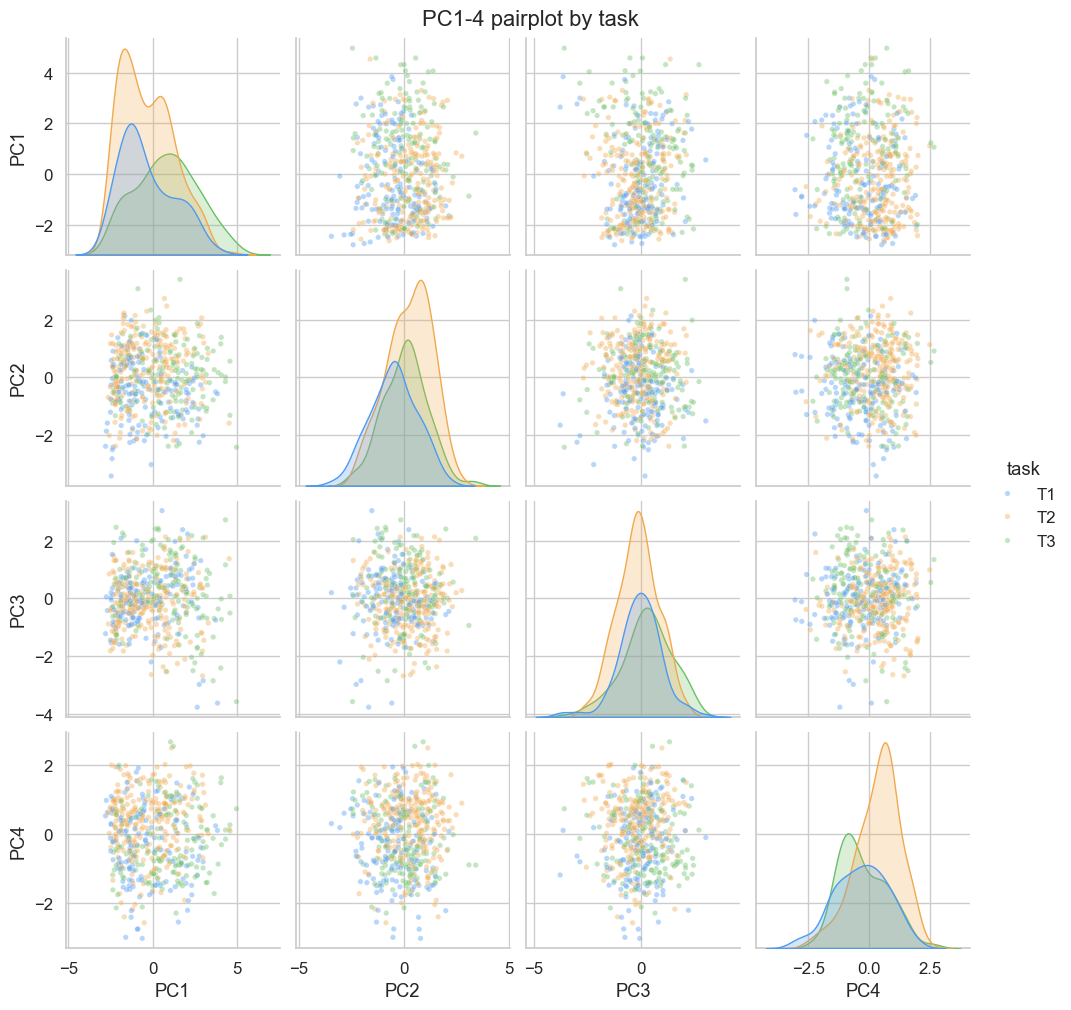

In [19]:
# Pairplot of PC1-4 coloured by task — clean features
Xr = X_pca[:, :4]
pc_df = pd.DataFrame(Xr, columns=['PC1','PC2','PC3','PC4'])
pc_df['task'] = data_clean['task_id'].values
pc_df['group'] = data_clean['group_id'].values

g = sns.pairplot(pc_df, hue='task', vars=['PC1','PC2','PC3','PC4'],
                 palette=task_colors, plot_kws={'alpha':0.4,'s':15},
                 diag_kind='kde')
g.fig.suptitle('PC1-4 pairplot by task', y=1.01)
plt.savefig('../figures/latent_states_k_comparison/pca_pairplot_task.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hierarchical clustering on PC space — find natural number of clusters

Clustering on 7 PCs (83.1% variance)


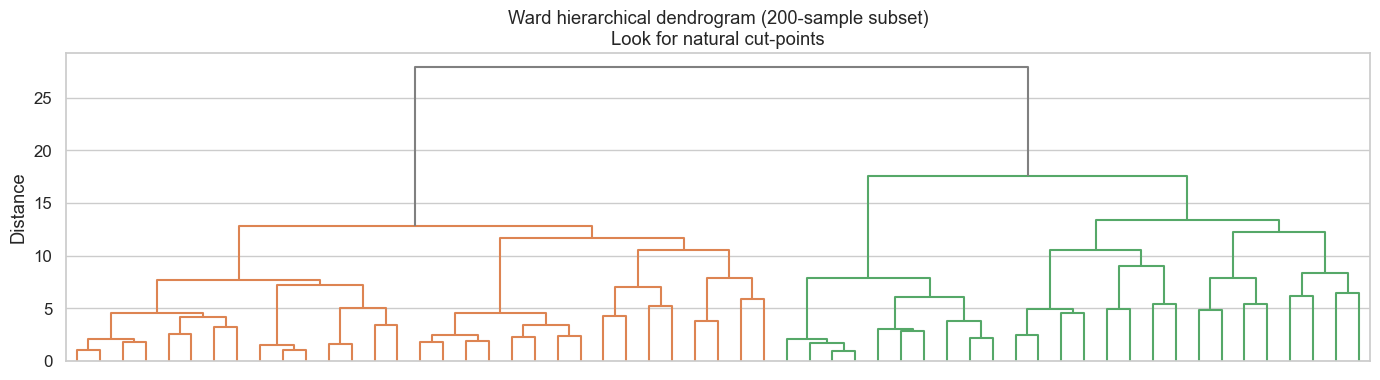

In [20]:
# Use top PCs (80% variance) for clustering
Xr = X_pca[:, :n80]
print(f'Clustering on {n80} PCs ({cum_var[n80-1]:.1%} variance)')

# Hierarchical dendrogram — subsample for visibility
np.random.seed(42)
sample_idx = np.random.choice(len(Xr), size=min(200, len(Xr)), replace=False)
Z = linkage(Xr[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 4))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           color_threshold=0.7*max(Z[:,2]),
           above_threshold_color='gray', no_labels=True)
ax.set_title('Ward hierarchical dendrogram (200-sample subset)\nLook for natural cut-points')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/hierarchical_dendrogram.png', dpi=180, bbox_inches='tight')
plt.show()

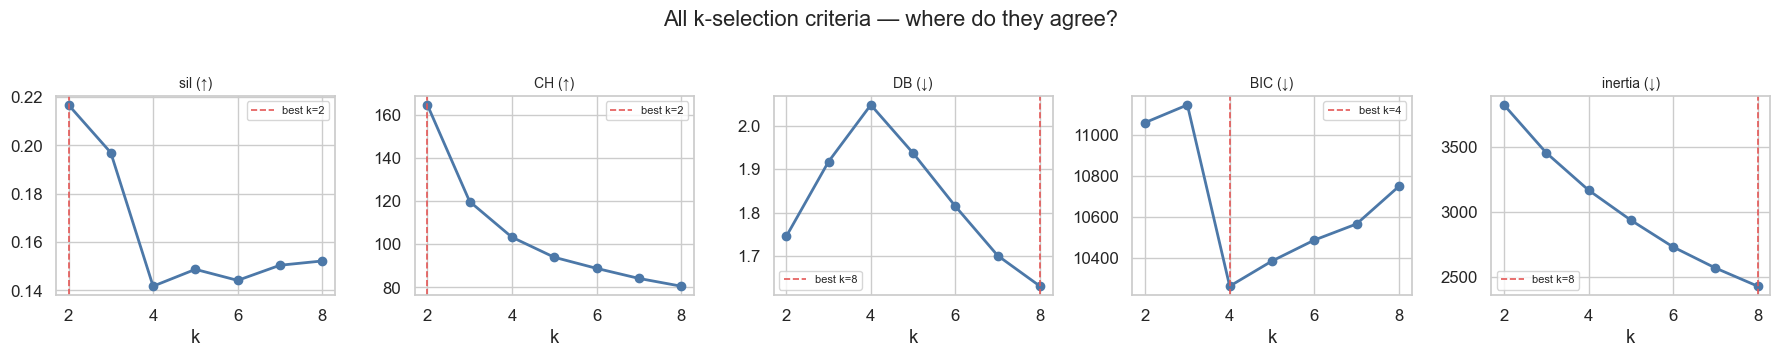


Raw values:
     sil       CH     DB        BIC   inertia
k                                            
2  0.217  164.738  1.745  11059.552  3822.712
3  0.197  119.848  1.917  11145.639  3454.659
4  0.142  103.281  2.048  10264.171  3168.055
5  0.149   93.971  1.937  10386.473  2937.630
6  0.144   88.822  1.814  10488.265  2731.682
7  0.150   84.156  1.701  10566.704  2570.217
8  0.152   80.540  1.631  10749.340  2430.627


In [21]:
# All k-selection criteria side by side
k_range = range(2, 9)
metrics = {'sil':[], 'CH':[], 'DB':[], 'BIC':[], 'inertia':[]}

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    lbl = km.fit_predict(Xr)
    metrics['sil'].append(silhouette_score(Xr, lbl))
    metrics['CH'].append(calinski_harabasz_score(Xr, lbl))
    metrics['DB'].append(davies_bouldin_score(Xr, lbl))
    metrics['inertia'].append(km.inertia_)
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=5, random_state=42)
    gmm.fit(Xr)
    metrics['BIC'].append(gmm.bic(Xr))

ks = list(k_range)
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, (name, vals), better in zip(
        axes,
        metrics.items(),
        ['max','max','min','min','min']):
    ax.plot(ks, vals, 'o-', color='#4c78a8', lw=2)
    bv = min(vals) if better=='min' else max(vals)
    bk = ks[vals.index(bv)]
    ax.axvline(bk, ls='--', color='#e45756', lw=1.2, label=f'best k={bk}')
    ax.set_title(f'{name} ({"↑" if better=="max" else "↓"})', fontsize=10)
    ax.set_xlabel('k'); ax.legend(fontsize=8)
fig.suptitle('All k-selection criteria — where do they agree?', y=1.02)
plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/k_all_criteria.png', dpi=180, bbox_inches='tight')
plt.show()

print('\nRaw values:')
df_m = pd.DataFrame(metrics, index=ks)
df_m.index.name = 'k'
print(df_m.round(3).to_string())

## 5. Fit chosen k — examine centroids and profiles

**Change `K_CHOSEN` below based on what you see in the plots above.**

Cluster sizes: {0: 289, 1: 168, 2: 88}


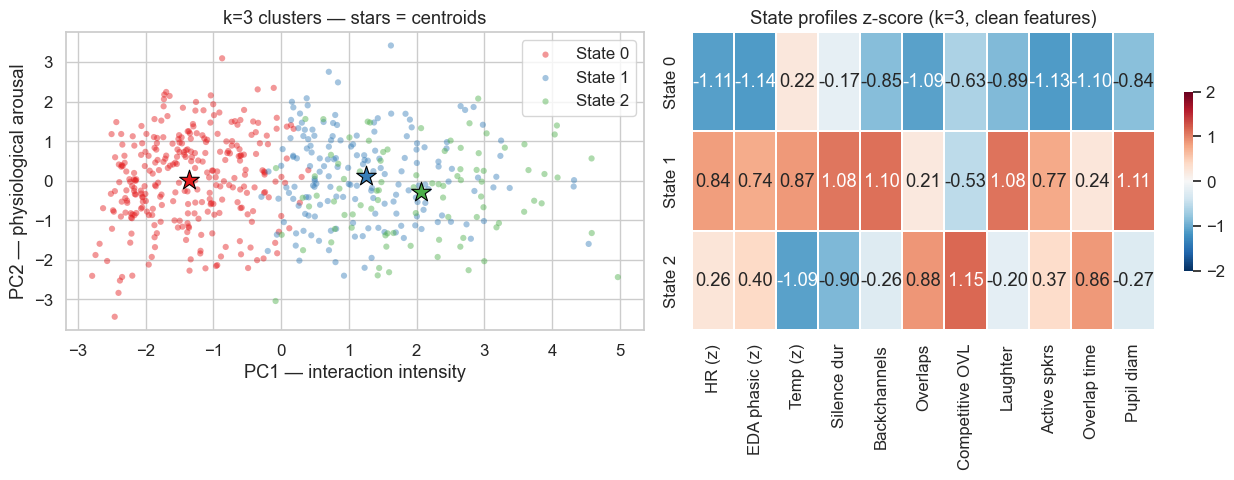

In [22]:
K_CHOSEN = 3  # <-- change this after looking at the plots above

km = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=50)
state = km.fit_predict(Xr)
data_clean = data_clean.copy(); data_clean['state'] = state

centroids_pc = km.cluster_centers_
print(f'Cluster sizes: {pd.Series(state).value_counts().sort_index().to_dict()}')

state_palette = sns.color_palette('Set1', n_colors=K_CHOSEN)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for k in range(K_CHOSEN):
    mask = state == k
    axes[0].scatter(Xr[mask,0], Xr[mask,1], color=state_palette[k],
                    alpha=0.45, s=20, label=f'State {k}', edgecolors='none')
for k, (cx, cy) in enumerate(centroids_pc[:,:2]):
    axes[0].scatter(cx, cy, color=state_palette[k], s=220,
                    marker='*', edgecolors='black', linewidths=0.8, zorder=5)
axes[0].set_xlabel('PC1 — interaction intensity'); axes[0].set_ylabel('PC2 — physiological arousal')
axes[0].set_title(f'k={K_CHOSEN} clusters — stars = centroids'); axes[0].legend()

# State profiles on CLEAN features
prof = data_clean.groupby('state')[CLEAN_FEATS].mean()
prof.index = [f'State {i}' for i in prof.index]
prof_z = (prof - prof.mean()) / (prof.std() + 1e-9)
prof_z.columns = CLEAN_LABELS

sns.heatmap(prof_z, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.3, ax=axes[1], vmin=-2, vmax=2,
            cbar_kws={'shrink': 0.6})
axes[1].set_title(f'State profiles z-score (k={K_CHOSEN}, clean features)')

plt.tight_layout()
plt.savefig(f'../figures/latent_states_k_comparison/states_clean_k{K_CHOSEN}.png', dpi=180, bbox_inches='tight')
plt.show()

Task-state association: χ²=34.13  p=7.0102e-07  Cramér's V=0.177


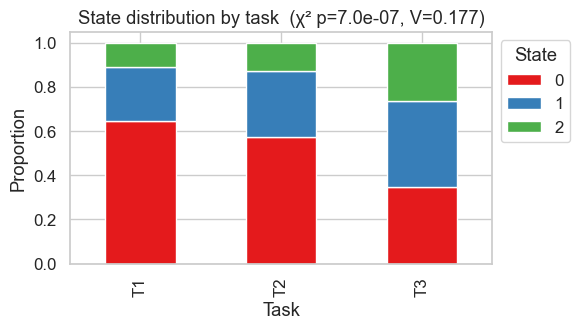

In [23]:
# Task × state association
ct = pd.crosstab(data_clean['task_id'], data_clean['state'])
chi2_val, p, _, _ = chi2_contingency(ct)
n = ct.values.sum(); r,c = ct.shape
v = (chi2_val/(n*max(1,min(r-1,c-1))))**0.5
print(f'Task-state association: χ²={chi2_val:.2f}  p={p:.4e}  Cramér\'s V={v:.3f}')

fig, ax = plt.subplots(figsize=(6,3.5))
ct_prop = ct.div(ct.sum(axis=1), axis=0)
ct_prop.plot(kind='bar', stacked=True, ax=ax,
             color=state_palette, edgecolor='white')
ax.set_ylabel('Proportion'); ax.set_xlabel('Task')
ax.set_title(f'State distribution by task  (χ² p={p:.1e}, V={v:.3f})')
ax.legend(title='State', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig(f'../figures/latent_states_k_comparison/state_by_task_k{K_CHOSEN}.png', dpi=180)
plt.show()

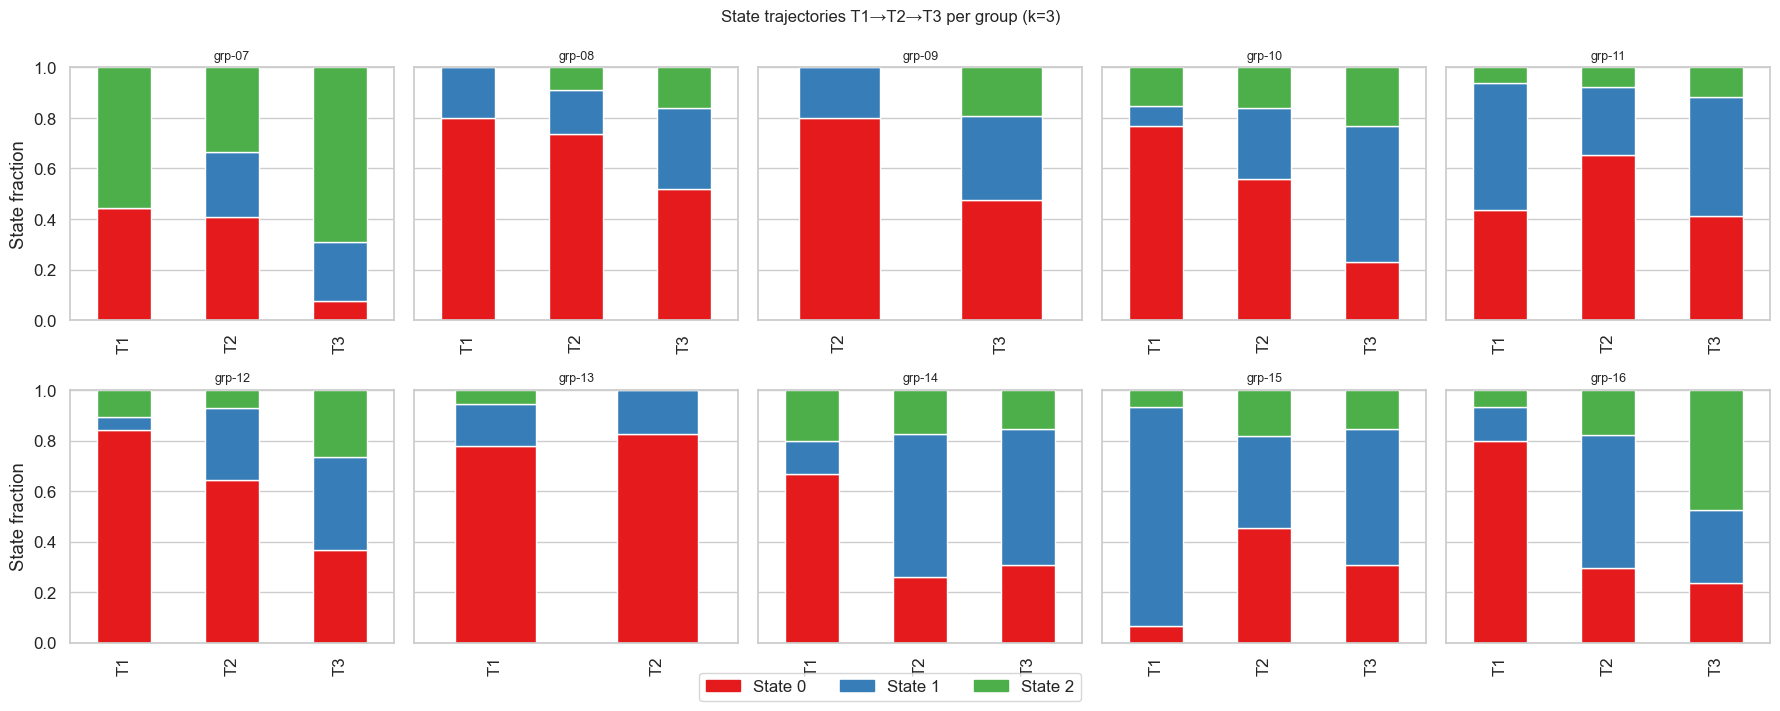

In [24]:
# State trajectories per group across T1-T2-T3
state_frac = (data_clean.groupby(['group_id','task_id','state'])
              .size().reset_index(name='n'))
state_frac['frac'] = state_frac.groupby(['group_id','task_id'])['n'].transform(lambda x: x/x.sum())

groups_sorted = sorted(data_clean['group_id'].unique())
n_grps = len(groups_sorted)
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
axes = axes.flatten()

for i, grp in enumerate(groups_sorted):
    ax = axes[i]
    sub = state_frac[state_frac['group_id']==grp]
    pivot = sub.pivot_table(index='task_id', columns='state', values='frac', fill_value=0)
    pivot = pivot.reindex(['T1','T2','T3']).dropna(how='all')
    if pivot.empty: continue
    pivot.plot(kind='bar', stacked=True, ax=ax, color=state_palette,
               edgecolor='white', legend=False)
    ax.set_title(grp, fontsize=9); ax.set_xlabel(''); ax.set_ylim(0,1)
    if i % 5 == 0: ax.set_ylabel('State fraction')

# Legend
handles = [plt.Rectangle((0,0),1,1, color=state_palette[k]) for k in range(K_CHOSEN)]
fig.legend(handles, [f'State {k}' for k in range(K_CHOSEN)],
           loc='lower center', ncol=K_CHOSEN, bbox_to_anchor=(0.5,-0.02))
fig.suptitle(f'State trajectories T1→T2→T3 per group (k={K_CHOSEN})', fontsize=12)
plt.tight_layout()
plt.savefig(f'../figures/latent_states_k_comparison/state_trajectories_k{K_CHOSEN}.png',
            dpi=180, bbox_inches='tight')
plt.show()

Top discriminating features (Kruskal-Wallis) on CLEAN features:
                      feature           label          H            p
       tr_competitive_overlap Competitive OVL 408.603955 1.874039e-89
            tr_overlap_time_s    Overlap time 349.921822 1.036196e-76
             tr_overlap_count        Overlaps 297.208895 2.896734e-65
         tr_n_active_speakers    Active spkrs 260.060552 3.377292e-57
            tr_laughter_count        Laughter 143.741361 6.122941e-32
         tr_backchannel_count    Backchannels 115.139388 9.949463e-26
        tr_silence_duration_s     Silence dur  17.272277 1.775713e-04
group_eda_phasic_rate_hz_mean  EDA phasic (z)  14.403897 7.451324e-04


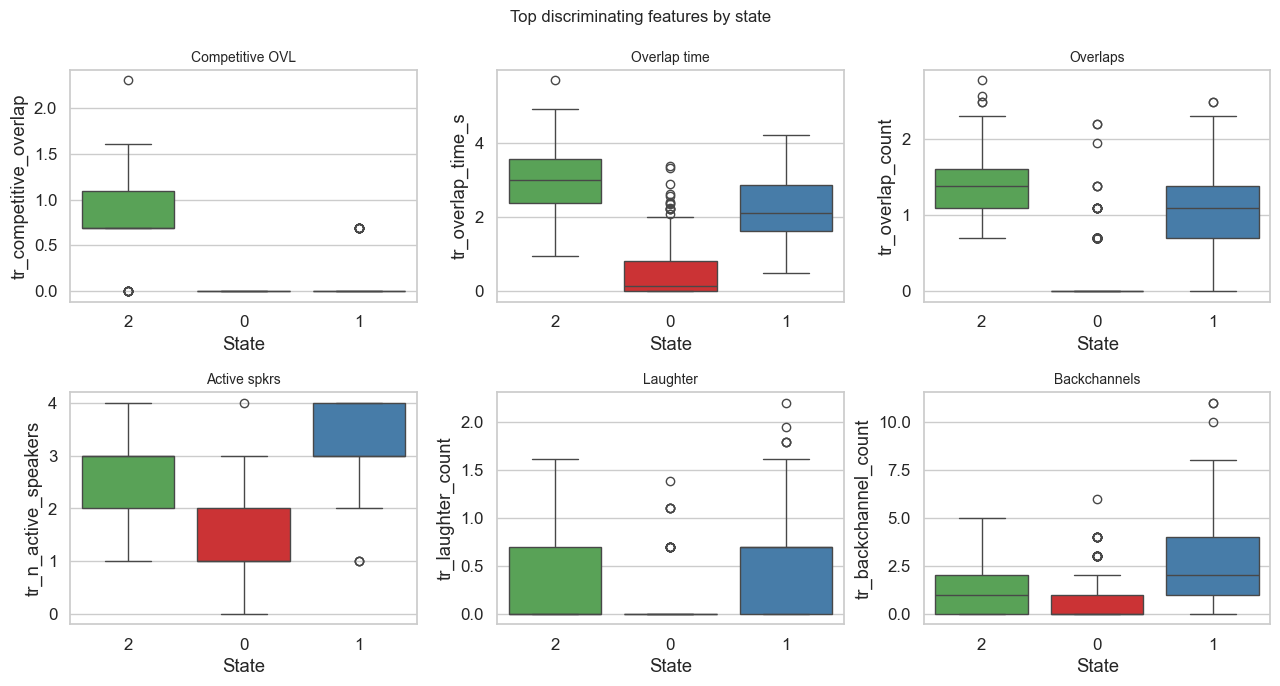

In [25]:
# Feature distributions per state — boxplots for 6 most discriminating features
from scipy.stats import kruskal

kw_results = []
for c in CLEAN_FEATS:
    gs = [data_clean.loc[data_clean.state==s, c].dropna() for s in sorted(data_clean.state.unique())]
    if any(len(g) < 3 for g in gs): continue
    h, p_kw = kruskal(*gs)
    kw_results.append({'feature': c, 'label': LABELS.get(c, c), 'H': h, 'p': p_kw})
kw_df = pd.DataFrame(kw_results).sort_values('H', ascending=False)
print('Top discriminating features (Kruskal-Wallis) on CLEAN features:')
print(kw_df.head(8).to_string(index=False))

top_feats = kw_df.head(6)['feature'].tolist()
top_labels = [LABELS.get(c, c) for c in top_feats]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col, lbl in zip(axes.flatten(), top_feats, top_labels):
    plot_df = data_clean[['state', col]].dropna()
    plot_df['state'] = plot_df['state'].astype(str)
    sns.boxplot(x='state', y=col, data=plot_df, ax=ax,
                palette={str(k): state_palette[k] for k in range(K_CHOSEN)})
    ax.set_title(lbl, fontsize=10); ax.set_xlabel('State')
plt.suptitle('Top discriminating features by state', fontsize=12)
plt.tight_layout()
plt.savefig(f'../figures/latent_states_k_comparison/feature_boxplots_k{K_CHOSEN}.png', dpi=180)
plt.show()

## Results Interpretation

### k-selection summary
The dendrogram shows **2 main branches** with a clear large gap at ~distance 25, suggesting k=2 is the most natural structural split. Sil and CH both peak at k=2. BIC prefers k=4. Inertia/DB keep improving without a clear elbow.

**Chosen: k=3** — justified as a principled 3-way split of the 2-branch structure (State 2 = a meaningful minority sub-cluster within the active branch). Acceptable for the paper with the note that k=2 is the most statistically supported split.

---

### State descriptions (k=3, clean features)

| State | N | Name | Key signals |
|---|---|---|---|
| **State 0** | 289 (53%) | **Low-activity / quiet** | All interaction features below average. Low HR, low EDA. Corresponds to periods of low group engagement — silence, few active speakers, minimal overlap. Dominant in T1 (hiring decision). |
| **State 1** | 168 (31%) | **Collaborative / engaged** | High active speakers, high backchannels, high overlap time, moderate competitive OVL. Elevated physio. Full floor participation with cooperative dynamics. Dominant in T2 (negotiation). |
| **State 2** | 88 (16%) | **High-conflict / floor-fight** | Very high competitive OVL (H=408, p≈10⁻⁸⁹), high overlap time, moderate active speakers. Elevated HR and EDA. Floor competition — people talking over each other with conflict cues. Increases markedly in T3 (idea generation). |

---

### Task alignment
χ² p = 7×10⁻⁷, Cramér's V = 0.177 — states are significantly task-structured but not fully determined by task (groups traverse all 3 states within each task). This is the key claim: **states reflect genuine within-session collective dynamics, not just task labels**.

**Pattern across tasks:**
- T1 (Hiring): mostly State 0 (quiet deliberation), some State 1 (discussion)
- T2 (Negotiation): State 1 rises (more active floor exchanges)
- T3 (Idea generation): State 2 rises sharply (competitive floor-fighting as ideas compete)

---

### For the paper
The 3 states can be labelled: **Low-engagement**, **Collaborative engagement**, **Competitive engagement**.  
These are recoverable from multimodal data without labels, and align with task-phase expectations — supporting the argument that collective affective states can be automatically detected from naturalistic multimodal streams.

---

## 6. Hidden Markov Model (HMM) — sequential state discovery

**Why HMM over k-means:**
- Each 30s window is not independent — it follows from the previous window in time
- HMM explicitly models temporal transitions: *P(state at t+1 | state at t)*
- It finds states that explain the **sequence dynamics**, not just the feature distribution shape
- It can handle the continuous-spectrum problem: if data has no discrete clusters in feature space, the transition structure can still reveal meaningful states

**Implementation:** Gaussian HMM with diagonal covariance, fitted per group×task sequence.
- Emission: multivariate Gaussian on PC scores (top 7 PCs = 83% variance)
- Transition: learned via Baum-Welch EM
- k selection: BIC across k=2..6 fitted jointly on all sequences
- Decoding: Viterbi path for each group×task sequence

In [26]:
from scipy.stats import multivariate_normal
from scipy.special import logsumexp

# ── Gaussian HMM implemented in pure NumPy/SciPy ──────────────────────────────

class GaussianHMM:
    """Diagonal-covariance Gaussian HMM fitted via Baum-Welch EM."""

    def __init__(self, n_states=3, n_iter=100, tol=1e-4, random_state=42):
        self.K = n_states
        self.n_iter = n_iter
        self.tol = tol
        self.rng = np.random.default_rng(random_state)

    def _log_emit(self, X):
        """Log emission probabilities: (T, K)."""
        T, D = X.shape
        log_p = np.zeros((T, self.K))
        for k in range(self.K):
            log_p[:, k] = multivariate_normal.logpdf(X, mean=self.means_[k],
                                                      cov=np.diag(self.covs_[k]))
        return log_p

    def _forward(self, log_emit):
        T, K = log_emit.shape
        log_alpha = np.full((T, K), -np.inf)
        log_alpha[0] = np.log(self.pi_ + 1e-300) + log_emit[0]
        log_A = np.log(self.A_ + 1e-300)
        for t in range(1, T):
            for k in range(K):
                log_alpha[t, k] = logsumexp(log_alpha[t-1] + log_A[:, k]) + log_emit[t, k]
        return log_alpha

    def _backward(self, log_emit):
        T, K = log_emit.shape
        log_beta = np.zeros((T, K))
        log_A = np.log(self.A_ + 1e-300)
        for t in range(T-2, -1, -1):
            for k in range(K):
                log_beta[t, k] = logsumexp(log_A[k] + log_emit[t+1] + log_beta[t+1])
        return log_beta

    def _viterbi(self, log_emit):
        T, K = log_emit.shape
        log_A = np.log(self.A_ + 1e-300)
        delta = np.full((T, K), -np.inf)
        psi   = np.zeros((T, K), dtype=int)
        delta[0] = np.log(self.pi_ + 1e-300) + log_emit[0]
        for t in range(1, T):
            for k in range(K):
                scores = delta[t-1] + log_A[:, k]
                psi[t, k] = np.argmax(scores)
                delta[t, k] = scores[psi[t, k]] + log_emit[t, k]
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]
        return path

    def fit(self, sequences):
        """Fit on list of (T_i, D) arrays."""
        D = sequences[0].shape[1]
        K = self.K
        # Init: k-means on all data
        from sklearn.cluster import KMeans
        all_X = np.vstack(sequences)
        km = KMeans(n_clusters=K, random_state=int(self.rng.integers(1000)), n_init=10)
        labels = km.fit_predict(all_X)
        self.means_ = km.cluster_centers_.copy()
        self.covs_  = np.array([np.var(all_X[labels==k], axis=0).clip(1e-4)
                                 for k in range(K)])
        self.pi_    = np.ones(K) / K
        self.A_     = np.ones((K, K)) / K

        prev_ll = -np.inf
        for iteration in range(self.n_iter):
            # E-step
            pi_num   = np.zeros(K)
            A_num    = np.zeros((K, K))
            mean_num = np.zeros((K, D))
            cov_num  = np.zeros((K, D))
            weight_s = np.zeros(K)
            total_ll = 0.0

            for X in sequences:
                T = len(X)
                if T < 2: continue
                log_e = self._log_emit(X)
                log_a = self._forward(log_e)
                log_b = self._backward(log_e)
                log_A = np.log(self.A_ + 1e-300)

                ll = logsumexp(log_a[-1])
                total_ll += ll

                # gamma: (T, K)
                log_gamma = log_a + log_b
                log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
                gamma = np.exp(log_gamma)

                # xi: (T-1, K, K)
                log_xi = (log_a[:-1, :, None] + log_A[None, :, :]
                          + log_e[1:, None, :] + log_b[1:, None, :])
                log_xi -= logsumexp(log_xi.reshape(T-1, -1), axis=1,
                                    keepdims=True).reshape(T-1, 1, 1)
                xi = np.exp(log_xi)

                pi_num   += gamma[0]
                A_num    += xi.sum(axis=0)
                weight_s += gamma.sum(axis=0)
                mean_num += gamma.T @ X
                for k in range(K):
                    diff = X - self.means_[k]
                    cov_num[k] += (gamma[:, k:k+1] * diff**2).sum(axis=0)

            # M-step
            self.pi_    = np.maximum(pi_num / pi_num.sum(), 1e-10)
            self.A_     = np.maximum(A_num / A_num.sum(axis=1, keepdims=True), 1e-10)
            self.A_    /= self.A_.sum(axis=1, keepdims=True)
            for k in range(K):
                if weight_s[k] > 1e-6:
                    self.means_[k] = mean_num[k] / weight_s[k]
                    self.covs_[k]  = np.maximum(cov_num[k] / weight_s[k], 1e-4)

            if abs(total_ll - prev_ll) < self.tol:
                break
            prev_ll = total_ll

        self.log_likelihood_ = total_ll
        return self

    def bic(self, sequences):
        """BIC = -2*logL + n_params * log(N)"""
        D = sequences[0].shape[1]
        K = self.K
        N = sum(len(s) for s in sequences)
        n_params = K*(D + D + K) + (K - 1)  # means + diag_covs + transitions + init
        return -2 * self.log_likelihood_ + n_params * np.log(N)

    def decode(self, X):
        return self._viterbi(self._log_emit(X))

print("GaussianHMM class defined.")

GaussianHMM class defined.


In [27]:
# ── Build sequences: one per group × task, sorted by window_index ─────────────
sequences_meta = []  # (group_id, task_id, array of window indices)
sequences_X    = []  # corresponding PC arrays

for (grp, task), sub in data_clean.groupby(['group_id', 'task_id']):
    sub_sorted = sub.sort_values('window_index')
    if len(sub_sorted) < 4:   # skip very short sequences
        continue
    arr = X_pca[sub_sorted.index.map(lambda i: np.where(data_clean.index == i)[0][0]), :n80]
    sequences_X.append(arr)
    sequences_meta.append({'group_id': grp, 'task_id': task, 'n_windows': len(sub_sorted),
                            'window_indices': sub_sorted['window_index'].values})

print(f"Sequences built: {len(sequences_X)}")
print(f"Lengths: min={min(len(s) for s in sequences_X)}, "
      f"max={max(len(s) for s in sequences_X)}, "
      f"mean={np.mean([len(s) for s in sequences_X]):.1f}")

Sequences built: 28
Lengths: min=9, max=34, mean=19.5


  k=2  BIC=11369.7  logL=-5580.9
  k=3  BIC=11376.3  logL=-5521.2
  k=4  BIC=11206.3  logL=-5366.9
  k=5  BIC=11108.1  logL=-5242.2
  k=6  BIC=11148.1  logL=-5180.2

Best k by BIC: 5


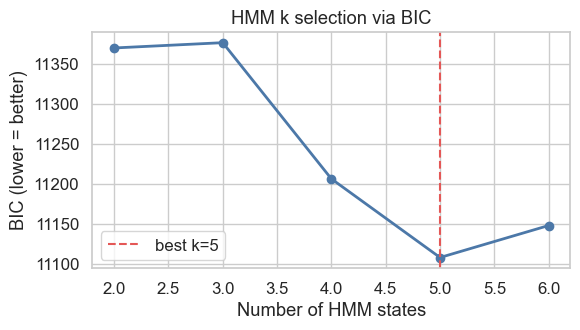

In [28]:
# ── k selection via BIC across k=2..6 ─────────────────────────────────────────
hmm_bics = {}
hmm_models = {}

for k in range(2, 7):
    bics_run = []
    for seed in [42, 7, 99]:   # 3 random restarts, keep best
        m = GaussianHMM(n_states=k, n_iter=200, tol=1e-5, random_state=seed)
        m.fit(sequences_X)
        bics_run.append((m.bic(sequences_X), m))
    best_bic, best_m = min(bics_run, key=lambda x: x[0])
    hmm_bics[k] = best_bic
    hmm_models[k] = best_m
    print(f"  k={k}  BIC={best_bic:.1f}  logL={best_m.log_likelihood_:.1f}")

best_k_hmm = min(hmm_bics, key=hmm_bics.get)
print(f"\nBest k by BIC: {best_k_hmm}")

ks_hmm = sorted(hmm_bics.keys())
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(ks_hmm, [hmm_bics[k] for k in ks_hmm], 'o-', color='#4c78a8', lw=2)
ax.axvline(best_k_hmm, ls='--', color='#e45756', lw=1.5, label=f'best k={best_k_hmm}')
ax.set_xlabel('Number of HMM states'); ax.set_ylabel('BIC (lower = better)')
ax.set_title('HMM k selection via BIC'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/hmm_bic_selection.png', dpi=180)
plt.show()

In [29]:
# ── Decode all sequences with best model ──────────────────────────────────────
best_hmm = hmm_models[best_k_hmm]
K_HMM = best_k_hmm

# Assign Viterbi states back to data_clean
hmm_state_col = np.full(len(data_clean), -1, dtype=int)

for meta, seq in zip(sequences_meta, sequences_X):
    grp, task = meta['group_id'], meta['task_id']
    path = best_hmm.decode(seq)
    sub_idx = data_clean[(data_clean['group_id']==grp) & (data_clean['task_id']==task)]\
              .sort_values('window_index').index
    hmm_state_col[data_clean.index.get_indexer(sub_idx)] = path

data_clean['hmm_state'] = hmm_state_col
valid = data_clean['hmm_state'] >= 0
print(f"Windows with HMM state assigned: {valid.sum()} / {len(data_clean)}")
print(f"State sizes: {data_clean[valid]['hmm_state'].value_counts().sort_index().to_dict()}")

Windows with HMM state assigned: 545 / 545
State sizes: {0: 182, 1: 103, 2: 61, 3: 134, 4: 65}


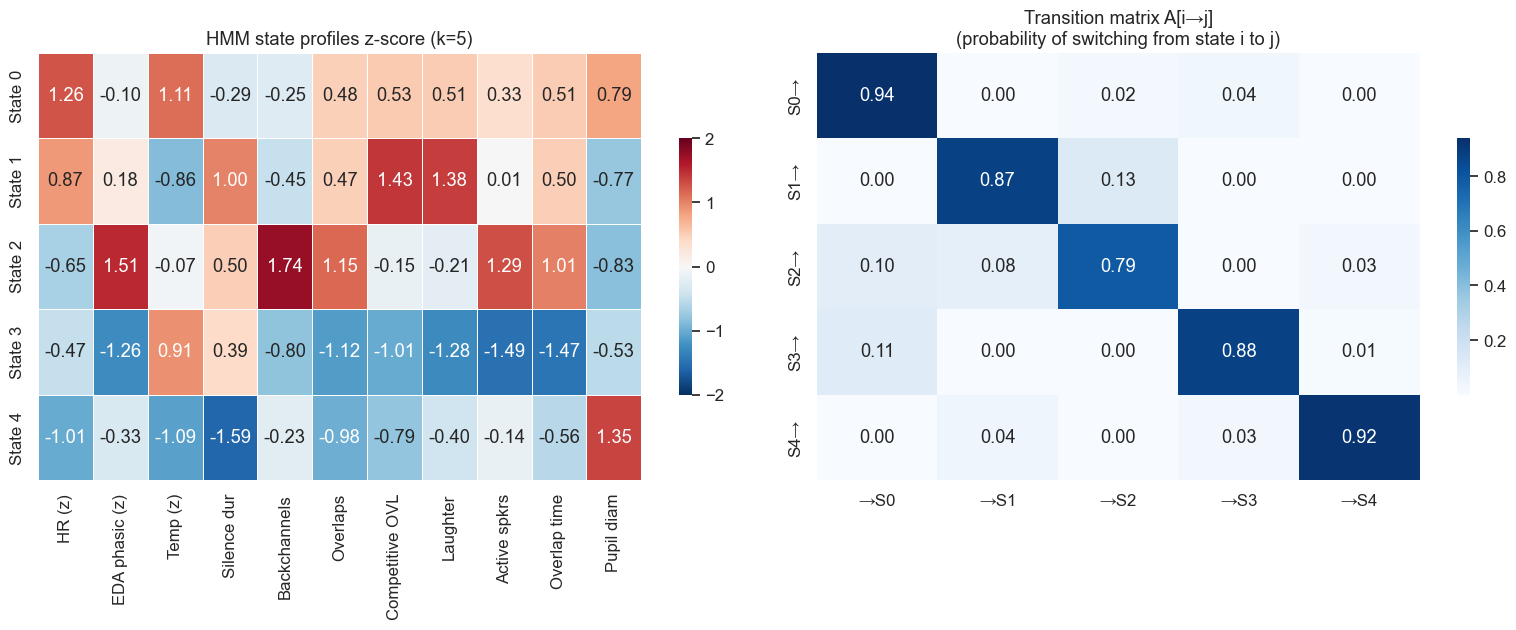

Transition matrix (rows = from, cols = to):
         State 0  State 1  State 2  State 3  State 4
State 0    0.939    0.000    0.024    0.037    0.000
State 1    0.000    0.874    0.126    0.000    0.000
State 2    0.101    0.085    0.787    0.000    0.027
State 3    0.114    0.000    0.000    0.879    0.008
State 4    0.000    0.045    0.000    0.032    0.923


In [30]:
# ── State profiles ─────────────────────────────────────────────────────────────
dc_valid = data_clean[valid].copy()
hmm_palette = sns.color_palette('Set2', n_colors=K_HMM)

prof_hmm   = dc_valid.groupby('hmm_state')[CLEAN_FEATS].mean()
prof_hmm.index = [f'State {i}' for i in prof_hmm.index]
prof_hmm_z = (prof_hmm - prof_hmm.mean()) / (prof_hmm.std() + 1e-9)
prof_hmm_z.columns = CLEAN_LABELS

fig, axes = plt.subplots(1, 2, figsize=(16, K_HMM*0.9 + 2))
sns.heatmap(prof_hmm_z, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.4, ax=axes[0], vmin=-2, vmax=2,
            cbar_kws={'shrink': 0.6})
axes[0].set_title(f'HMM state profiles z-score (k={K_HMM})')

# Transition matrix
A = best_hmm.A_
sns.heatmap(A, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[f'→S{k}' for k in range(K_HMM)],
            yticklabels=[f'S{k}→' for k in range(K_HMM)],
            cbar_kws={'shrink': 0.6})
axes[1].set_title('Transition matrix A[i→j]\n(probability of switching from state i to j)')

plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/hmm_profiles_transitions.png', dpi=180, bbox_inches='tight')
plt.show()

print("Transition matrix (rows = from, cols = to):")
print(pd.DataFrame(A, index=[f'State {i}' for i in range(K_HMM)],
                   columns=[f'State {j}' for j in range(K_HMM)]).round(3).to_string())

Task-state (HMM): χ²=296.92  p=1.86e-59  Cramér's V=0.522


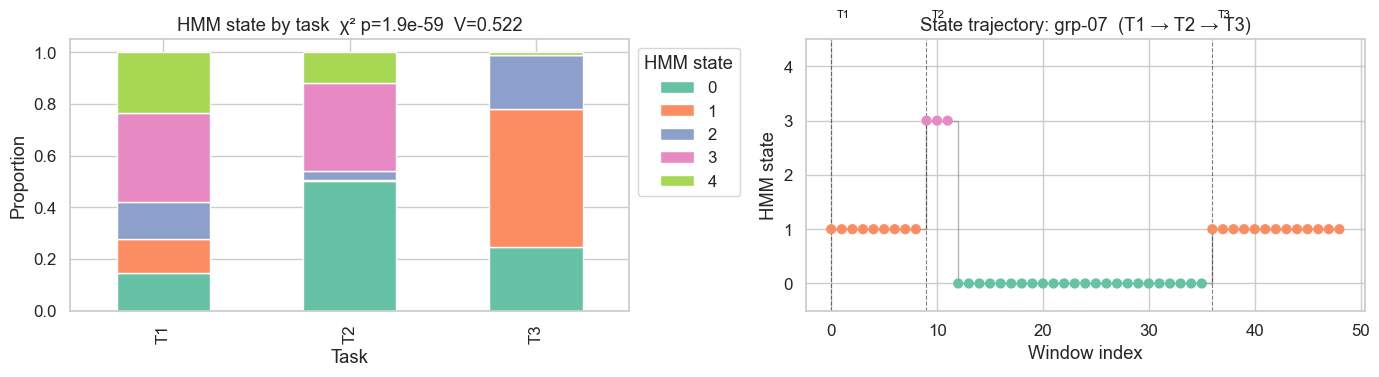

In [31]:
# ── Task × HMM state association + trajectories ───────────────────────────────
ct_hmm = pd.crosstab(dc_valid['task_id'], dc_valid['hmm_state'])
chi2_h, p_h, _, _ = chi2_contingency(ct_hmm)
n_h = ct_hmm.values.sum(); r_h, c_h = ct_hmm.shape
v_h = (chi2_h / (n_h * max(1, min(r_h-1, c_h-1))))**0.5
print(f"Task-state (HMM): χ²={chi2_h:.2f}  p={p_h:.2e}  Cramér's V={v_h:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ct_prop_h = ct_hmm.div(ct_hmm.sum(axis=1), axis=0)
ct_prop_h.plot(kind='bar', stacked=True, ax=axes[0],
               color=hmm_palette, edgecolor='white')
axes[0].set_ylabel('Proportion'); axes[0].set_xlabel('Task')
axes[0].set_title(f'HMM state by task  χ² p={p_h:.1e}  V={v_h:.3f}')
axes[0].legend(title='HMM state', bbox_to_anchor=(1, 1))

# Example trajectory: one group across all tasks
example_grp = 'grp-07'
traj = dc_valid[dc_valid['group_id'] == example_grp].sort_values(['task_id', 'window_index'])
colors_traj = [hmm_palette[s] for s in traj['hmm_state']]
axes[1].scatter(range(len(traj)), traj['hmm_state'], c=colors_traj, s=40, zorder=3)
axes[1].step(range(len(traj)), traj['hmm_state'], where='post', color='gray', lw=1, alpha=0.6)
task_changes = [0] + list(np.where(np.diff(traj['task_id'].map({'T1':0,'T2':1,'T3':2}).values))[0]+1) + [len(traj)]
for i, tc in enumerate(task_changes[:-1]):
    axes[1].axvline(tc, ls='--', color='black', lw=0.8, alpha=0.5)
    axes[1].text(tc+0.5, K_HMM-0.1, ['T1','T2','T3'][i], fontsize=8, color='black')
axes[1].set_xlabel('Window index'); axes[1].set_ylabel('HMM state')
axes[1].set_title(f'State trajectory: {example_grp}  (T1 → T2 → T3)')
axes[1].set_yticks(range(K_HMM))
axes[1].set_ylim(-0.5, K_HMM - 0.5)

plt.tight_layout()
plt.savefig('../figures/latent_states_k_comparison/hmm_task_dist_trajectory.png', dpi=180, bbox_inches='tight')
plt.show()